In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [104]:
df = pd.read_csv('bangladesh_student_performance_updated.csv')

In [105]:
df.shape

(2018, 16)

In [106]:
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
533,29/04/2018,F,18.0,Rural,LE3,Together,0,1,Other,Farmer,No,No,57343.0,1,2.85,2.61
313,29/04/2018,F,17.0,Rural,LE3,Together,0,2,Services,Business,No,No,31073.0,1,4.30,3.85
1123,29/04/2018,F,18.0,Urban,GT3,Together,1,0,Services,Teacher,No,No,85960.0,3,4.47,3.63
814,29/04/2018,F,19.0,Urban,GT3,Together,3,3,Teacher,Services,No,No,87347.0,3,3.53,3.26
1064,29/04/2018,M,18.0,Rural,GT3,Apart,3,2,Other,Farmer,No,No,49999.0,1,3.76,3.45
1903,29/04/2018,M,18.0,Urban,GT3,Together,0,3,Other,Teacher,No,No,83070.0,5,4.41,3.62
94,29/04/2018,F,18.0,Urban,GT3,Together,4,0,Teacher,Business,No,No,92782.0,2,4.21,3.67
165,29/04/2018,F,17.0,Rural,GT3,Together,0,1,NaN,Business,No,No,53071.0,5,4.24,3.26
1736,29/04/2018,M,18.0,Rural,GT3,Together,2,4,Services,Farmer,No,No,47697.0,2,3.10,2.58
481,29/04/2018,F,18.0,Rural,GT3,Together,2,3,Services,Farmer,Yes,No,62846.0,2,2.98,2.76


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [108]:
df['time_friends'].unique()
df['M_Edu'].unique()
df['famsize'].unique()

array(['GT3', 'LE3'], dtype=object)

In [109]:
df.isnull().sum()

,0
date,0
gender,0
age,35
address,35
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,35
F_Job,0


In [110]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [111]:
df.duplicated().sum()

np.int64(0)

Text(0.5, 0.98, 'Distribution of Numerical Features')

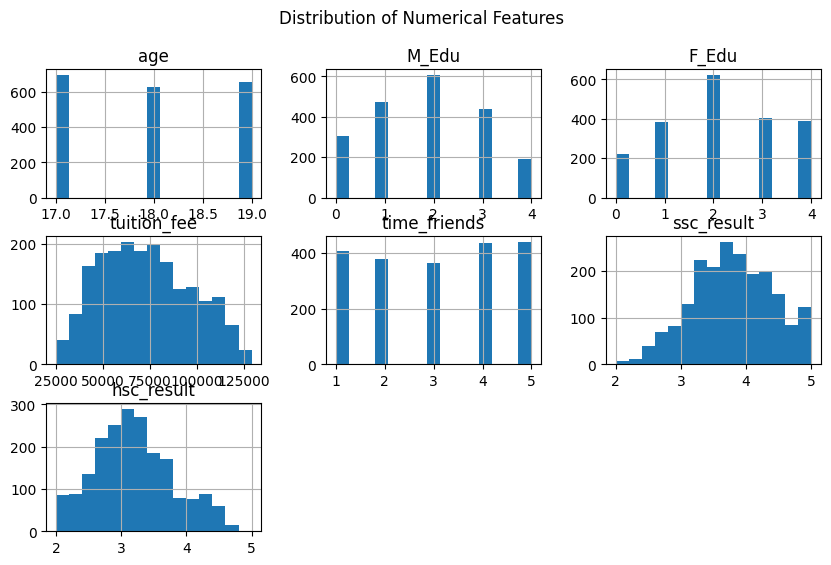

In [112]:
df.hist(bins=15, figsize=(10,6))

plt.suptitle('Distribution of Numerical Features')

In [113]:
numerical_cols = ['age', 'tuition_fee', 'ssc_result', 'hsc_result']

df[numerical_cols].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


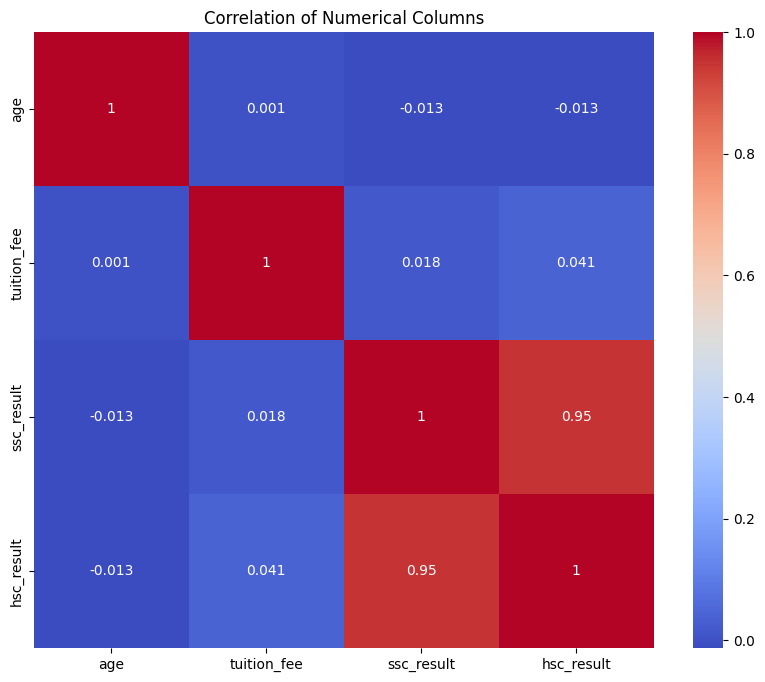

In [114]:
plt.figure(figsize=(10,8))

sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation of Numerical Columns")

plt.show()

<Axes: xlabel='ssc_result'>

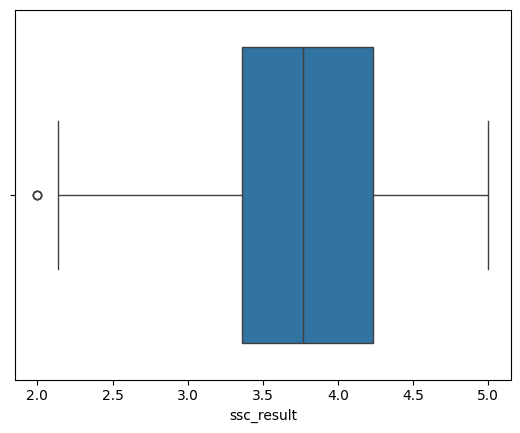

In [115]:
sns.boxplot(data=df, x='ssc_result')

# Preprocessing

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline

In [117]:
nominal_cat = ['gender', 'address','famsize','Pstatus','relationship', 'smoker','M_Job','F_Job']

# ordinal_cat = ['M_Edu','F_Edu', 'time_friends']

# M_edu_order = [i for i in range(df['M_Edu'].min(), df['M_Edu'].max()+1)]
# F_edu_order = [i for i in range(df['F_Edu'].min(), df['F_Edu'].max()+1)]
# time_friends_order = [i for i in range(df['time_friends'].max(), df['time_friends'].min()-1, -1)]

numerical_cols = ['age', 'tuition_fee', 'ssc_result']



In [118]:
numerical_transformers = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)
numerical_transformers

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

In [119]:
nominal_transformers = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

nominal_transformers

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [120]:
# ordinal_transformers = Pipeline(
#     steps=[
#         ('imputer', SimpleImputer(strategy='most_frequent')),
#         ('encoder', OrdinalEncoder(categories=[M_edu_order, F_edu_order, time_friends_order])),
#         ('scaler', MinMaxScaler())
#     ]
#   )

# ordinal_transformers

In [121]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformers, numerical_cols),
        ('nominal', nominal_transformers, nominal_cat),
        # ('ordinal', ordinal_transformers, ordinal_cat)
    ],
    remainder='passthrough'
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'tuition_fee', 'ssc_result']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'address', 'famsize', 'Pstatus',
                                  'relationship', 'smoker', 'M_Job',
                                  'F_Job'])])

In [122]:
X = df.drop(['date', 'hsc_result'], axis=1)
y = df['hsc_result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression

In [123]:
from sklearn.linear_model import LinearRegression, SGDRegressor

In [126]:
lr_pipe = Pipeline(
    steps=[
        ('preprocesssor', preprocessor),
        ('model', LinearRegression())
    ]
)

lr_pipe.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocesssor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'M_Job', 'F_Job'])])),
                ('model', LinearRegression())])

In [127]:
X_test

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,17.0,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743.0,1,3.88
526,M,19.0,Rural,GT3,Together,4,3,At_home,Business,No,No,58678.0,5,4.36
393,F,18.0,Urban,GT3,Together,2,1,Services,Services,No,No,115832.0,3,4.47
1789,M,17.0,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781.0,1,4.43
433,M,19.0,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481.0,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17.0,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345.0,4,3.47
693,M,19.0,Urban,GT3,Together,1,2,Health,Business,No,No,85346.0,4,2.96
1494,F,18.0,Rural,LE3,Together,1,4,Teacher,Teacher,No,No,30638.0,1,3.76
921,M,NaN,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804.0,2,4.18


In [128]:
lr_pipe.predict(X_test)

array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468,
       3.33301608, 3.9843285 , 2.54037997, 1.97886626, 3.27239028,
       3.67549746, 2.91990239, 3.23829796, 4.27797546, 3.03907632,
       2.67683989, 3.71729372, 3.45240833, 2.8064922 , 2.96057683,
       2.82062305, 3.20485147, 2.99957398, 3.21864928, 1.89881831,
       2.58370593, 3.18675035, 3.82959511, 3.08845188, 3.94801852,
       2.39854271, 3.94466671, 4.31696495, 2.56460476, 3.19397834,
       3.26413536, 2.75935124, 3.65848872, 2.48692797, 2.60907848,
       3.07614707, 2.97405288, 3.73760615, 2.76965129, 2.17795697,
       3.0682365 , 2.62107646, 2.60926091, 4.03558054, 3.26099047,
       3.07457897, 3.45268988, 4.23316558, 3.63562822, 3.07047904,
       3.19897028, 3.29199946, 2.67475419, 3.81647227, 2.67135675,
       3.00589862, 2.76737407, 2.49028194, 4.43360442, 2.5597574 ,
       3.21127693, 3.96661533, 2.67087186, 3.03353973, 3.22560591,
       3.03057043, 2.72163419, 2.61374344, 3.63605177, 3.07885

In [129]:
SGD_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SGDRegressor())
    ]
)

In [130]:
SGD_pipe.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'M_Job', 'F_Job'])])),
                ('model', SGDRegressor())])

In [131]:
SGD_pipe.predict(X_test)

array([3.22135171, 3.77684349, 3.83255142, 3.95271196, 3.84381218,
       3.34531344, 3.94851381, 2.51752623, 1.96335692, 3.28315634,
       3.68326022, 2.92665448, 3.2445079 , 4.27961625, 3.0550075 ,
       2.64307692, 3.72844723, 3.40399618, 2.81737012, 2.93537065,
       2.82953246, 3.21649633, 2.96309974, 3.19507068, 1.90324287,
       2.51160007, 3.20296534, 3.83917119, 3.06434928, 3.96111735,
       2.40443926, 3.96587282, 4.28489582, 2.58475086, 3.20947273,
       3.29277438, 2.76259864, 3.67186382, 2.50347097, 2.61680144,
       3.09049476, 2.97953857, 3.74606202, 2.78066629, 2.12515258,
       3.08323198, 2.63996417, 2.59980974, 3.99586979, 3.23355759,
       3.0658314 , 3.4507911 , 4.21542414, 3.62220971, 3.06438683,
       3.1580622 , 3.30881265, 2.67271806, 3.81784394, 2.61263255,
       3.02791796, 2.77366764, 2.48348551, 4.45235218, 2.5738343 ,
       3.21684971, 3.93609358, 2.68282564, 3.04005872, 3.20397187,
       3.03324136, 2.74263683, 2.61594492, 3.65450988, 3.08102

In [132]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [134]:
#linear regression

y_pred = lr_pipe.predict(X_test)

mse = round(mean_squared_error(y_test, y_pred),4)
mae = round(mean_absolute_error(y_test, y_pred),4)
rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)),4)
r2 = round(r2_score(y_test, y_pred),4)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Squared Error: 0.0203
Mean Absolute Error: 0.1114
Root Mean Squared Error: 0.1425
R-squared: 0.9459


In [135]:
#SGD Regression

#linear regression

y_pred = SGD_pipe.predict(X_test)

mse = round(mean_squared_error(y_test, y_pred),4)
mae = round(mean_absolute_error(y_test, y_pred),4)
rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)),4)
r2 = round(r2_score(y_test, y_pred),4)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Squared Error: 0.0202
Mean Absolute Error: 0.1116
Root Mean Squared Error: 0.1422
R-squared: 0.946
